In [4]:
from gc import set_debug
from multiprocessing.connection import default_family

from hometask8_din import pivot

pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#
# ✅ Topshirish talablari:
# Har bir grafik alohida plt.figure() bilan chizilsin.
# Grafiklar ostiga sarlavha (plt.title) yozilsin.
# Izohlar (comment) bilan tushuntirish yozilsin.

# 1. Faylni o`qigach Ma'lumotni tayyorlash

ds = pd.read_excel('sales_dataa.xlsx')
ds


,OrderID,Product,Category,Quantity,Price,Date
0,1,Phone,Electronics,2,300,2023-01-01
1,2,Headphones,Electronics,5,50,2023-01-02
2,3,T-shirt,Clothing,3,20,2023-01-03
3,4,Laptop,Electronics,1,1000,2023-01-04
4,5,Shoes,Clothing,2,80,2023-01-05
5,6,Tablet,Electronics,3,400,2023-01-06
6,7,Backpack,Accessories,4,60,2023-01-07
7,8,Watch,Electronics,1,200,2023-01-08
8,9,Charger,Accessories,6,15,2023-01-09
9,10,Mouse,Accessories,3,25,2023-01-10


In [36]:
# Yangi ustun yarating: Total = Quantity * Price
# Sanani Date ustuni bo‘yicha tartiblang

ds['Total'] = ds['Quantity'] * ds['Price']

ds = ds.sort_values('Date')
ds


,OrderID,Product,Category,Quantity,Price,Date,Total
0,1,Phone,Electronics,2,300,2023-01-01,600
1,2,Headphones,Electronics,5,50,2023-01-02,250
2,3,T-shirt,Clothing,3,20,2023-01-03,60
3,4,Laptop,Electronics,1,1000,2023-01-04,1000
4,5,Shoes,Clothing,2,80,2023-01-05,160
5,6,Tablet,Electronics,3,400,2023-01-06,1200
6,7,Backpack,Accessories,4,60,2023-01-07,240
7,8,Watch,Electronics,1,200,2023-01-08,200
8,9,Charger,Accessories,6,15,2023-01-09,90
9,10,Mouse,Accessories,3,25,2023-01-10,75


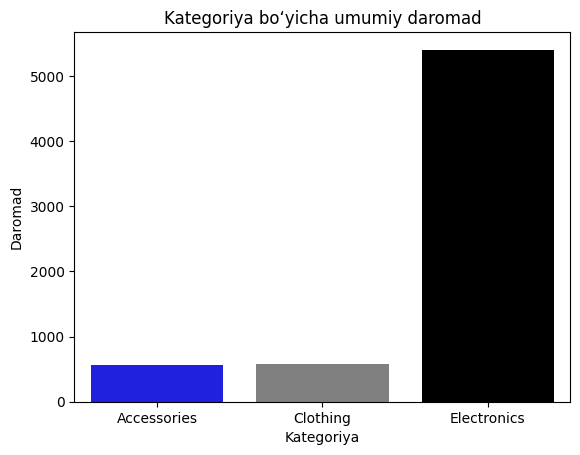

In [45]:
# 2. Barplot
# Har bir kategoriya bo‘yicha umumiy daromadni ustun shaklida ko‘rsating.

grouped = ds.groupby('Category')['Total'].sum().reset_index()

colors = []
colors = ['blue', 'grey', 'black']
sns.barplot(x='Category', y='Total', data=grouped, palette=colors, hue='Category',   legend=False) #hue → rang bilan guruhlash, #legend — bu diagrammadagi ranglar nimani anglatishini ko‘rsatadigan izoh
plt.title('Kategoriya bo‘yicha umumiy daromad')
plt.xlabel('Kategoriya')
plt.ylabel('Daromad')
plt.show()


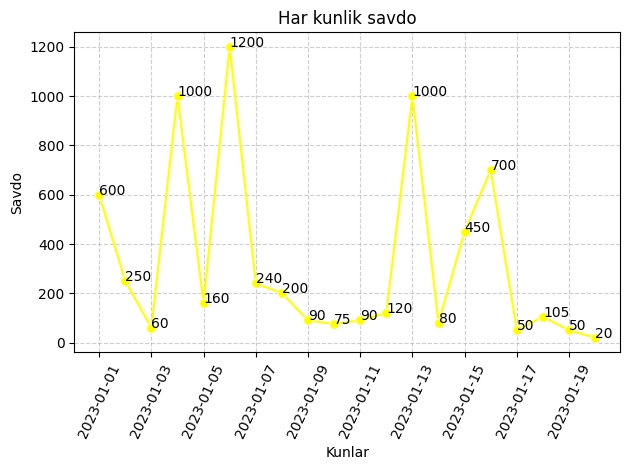

In [56]:
# 3. Lineplot
# Har bir kunlik savdoni trend ko‘rinishida chizing.

daily = ds.groupby('Date')['Total'].sum().reset_index()

ax = sns.lineplot(x='Date', y='Total', data=daily, color='yellow', marker='o', markersize=7)
plt.title('Har kunlik savdo')
plt.xticks(rotation=65)
plt.xlabel('Kunlar')
plt.ylabel('Savdo')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

for x, y in zip(daily['Date'], daily['Total']):
    ax.text(x, y, str(y))

plt.show()


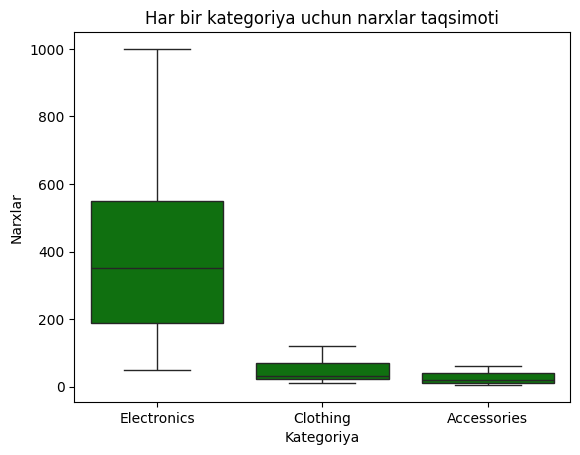

In [58]:
# 4. Boxplot
# Har bir kategoriya uchun narxlar taqsimotini boxplotda ko‘rsating.

sns.boxplot(x=ds['Category'], y=ds['Price'], color='green')
plt.title('Har bir kategoriya uchun narxlar taqsimoti')
plt.xlabel('Kategoriya')
plt.ylabel('Narxlar')

plt.show()


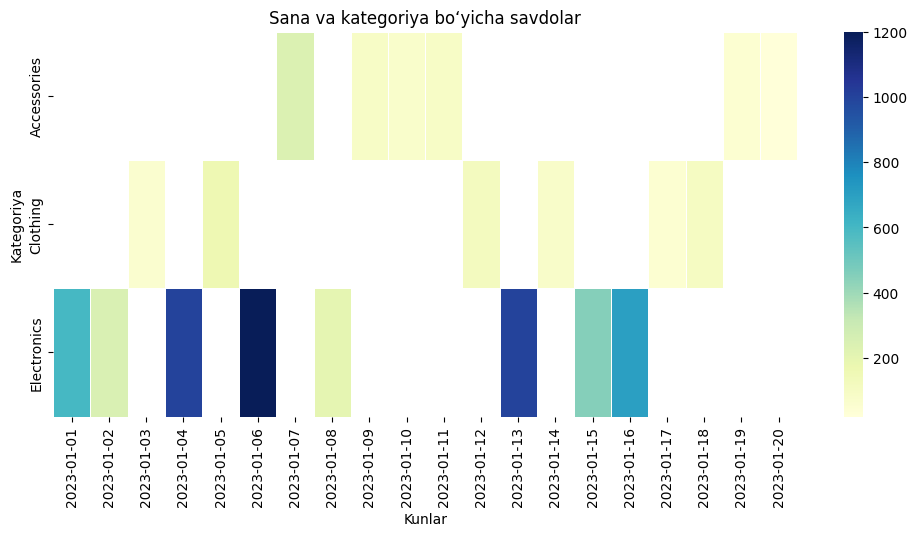

In [75]:
# 5. Heatmap
# pivot_table yordamida sana va kategoriya bo‘yicha savdolarni issiqlik xaritasi shaklida ko‘rsating.

pivot = pd.pivot_table(ds, values='Total', index='Category', columns='Date')

ds['Date'] = pd.to_datetime(ds['Date']).dt.date
plt.figure(figsize=(12,5))
sns.heatmap(pivot, cmap='YlGnBu', linewidths=0.5)

plt.title('Sana va kategoriya bo‘yicha savdolar')
plt.xlabel('Kunlar')
plt.ylabel('Kategoriya')
plt.xticks(rotation=90)

plt.show()

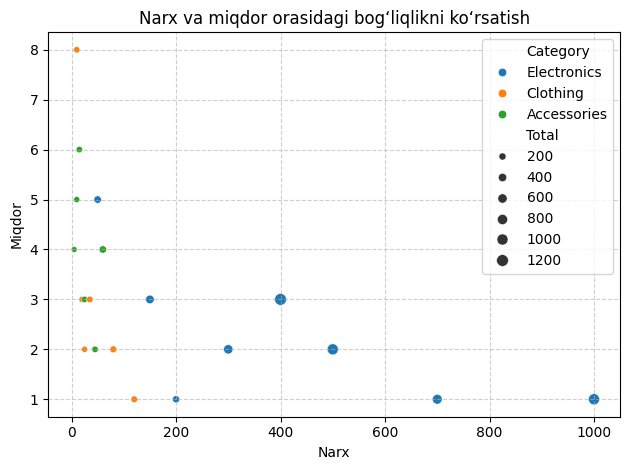

In [78]:
# 6. Scatterplot
# Narx va miqdor orasidagi bog‘liqlikni ko‘rsating, rang bo‘yicha kategoriya ajralsin, o‘lcham bo‘yicha Total.


sns.scatterplot(x=ds['Price'], y=ds['Quantity'], hue=ds['Category'], size=ds['Total'])

plt.title('Narx va miqdor orasidagi bog‘liqlikni ko‘rsatish')
plt.xlabel('Narx')
plt.ylabel('Miqdor')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()


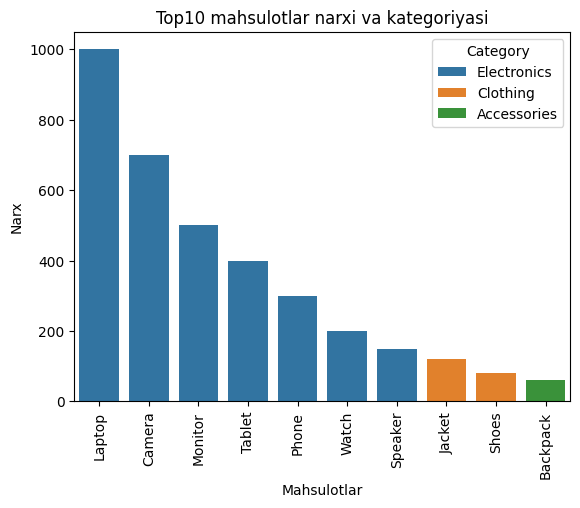

In [80]:
# 7. Bonus topshiriq (Advanced)
# Mahsulotlar orasida narxi eng yuqori bo‘lgan 10 ta mahsulotni ajrating va ularning Price va Category ustunlari asosida barplot chizing.

top_10 = ds.sort_values('Price', ascending=False).head(10)

sns.barplot(x='Product', y='Price', hue='Category', data=top_10)
plt.title('Top10 mahsulotlar narxi va kategoriyasi')
plt.xlabel('Mahsulotlar')
plt.ylabel('Narx')
plt.xticks(rotation=90)

plt.show()
